# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [38]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [39]:
filename="SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [40]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [41]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [42]:
Fisher.fit(X_Train,y_Train)

LinearDiscriminantAnalysis()

We can plot the output, comparing signal and background:

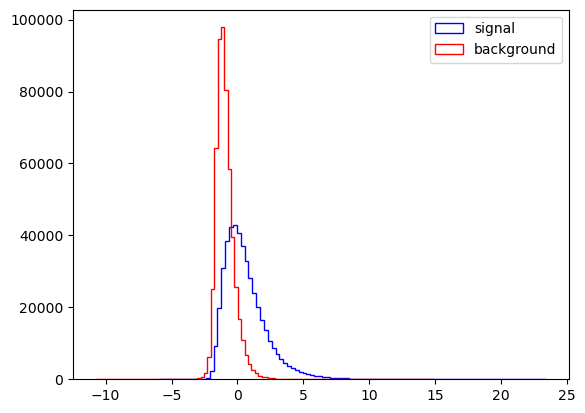

In [43]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

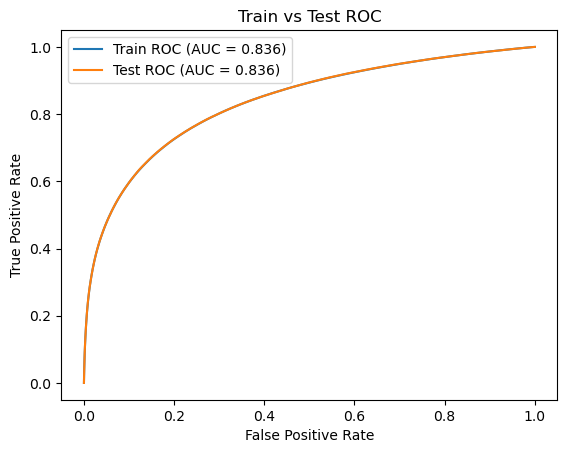

In [44]:
from sklearn.metrics import roc_curve, auc

# Training ROC: calculate ROC for the training data using the trained Fisher Discriminant
fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))
auc_train = auc(fpr_train, tpr_train)

# Testing ROC: calculate ROC for the testing data using the trained Fisher Discriminant
fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
auc_test = auc(fpr_test, tpr_test)

# Plot the Train ROC and Test ROC for comparison
plt.figure()
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("Train vs Test ROC")
plt.show()

**Part 'A' explanation**: The Train ROC and Test ROC seem to overlap with each other. In addition, their AUC values are also similar. This indicates that the model is generalizing well from the training data. A bias is not seen in this because since the AUC values of the Train and Test are the same, this implies that there is no overfitting bias present.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

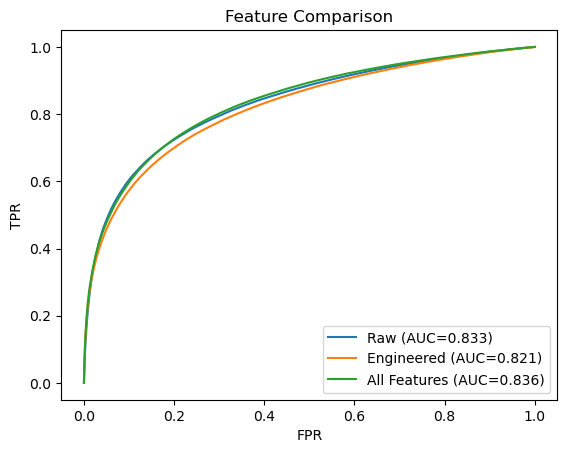

In [45]:
# Define feature groups (adjust indices if needed)
raw_features = VarNames[1:10]
eng_features = VarNames[10:]

# function to train an LDA classifier to evaluate its performance on the test set and plot ROC curve
def evaluate_features(features, label):
    # initialize a new LDA classifier
    Fisher = DA.LinearDiscriminantAnalysis()
    # train the classifier using the specified features from the training data
    Fisher.fit(X_Train[features], y_Train)
    
    # Compute ROC curve for the test set using the classifier's decision function
    fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test[features]))
    # Calculate the Area Under the ROC Curve (AUC)
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve with its AUC in the legend
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")

plt.figure()

# Evaluate and plot ROC for 'Raw' features
evaluate_features(raw_features, "Raw")
# Evaluate and plot ROC for 'Engineered' features
evaluate_features(eng_features, "Engineered")
# Evaluate and plot ROC for 'All Features' (both raw and engineered)
evaluate_features(VarNames[1:], "All Features")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("Feature Comparison")
plt.show()

**Part 'B' explanation**: The All Features ROC seems to have the best performance, indicating that using both the raw and engineered features together provides the most discriminatory power. All features also has the highest AUC value. The engineered ROC has the lowest AUC. This indicates that they are less effective on their own compared to the Raw features.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 6.

In [46]:
# Part a

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB

# Initialize Logistic Regression classifier
clf1 = LogisticRegression(max_iter=1000)

# Initialize Gaussian Naive Bayes classifier
clf2 = GaussianNB()

# Initialize Stochastic Gradient Descent (SGD) Classifier
clf3 = SGDClassifier(loss='log_loss')

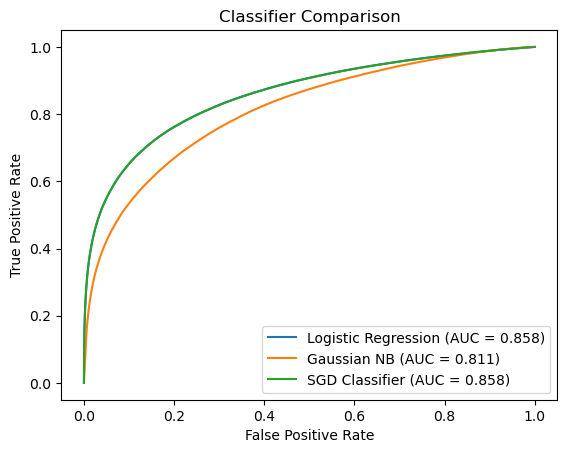

In [47]:
# Part b

# Function to train + evaluate + plot ROC
def compare_classifier(clf, name):
    # Train the classifier using the training data
    clf.fit(X_Train, y_Train)
    
    # Get scores. Use decision_function if available, otherwise use predict_proba for the probability of the positive class.
    if hasattr(clf, "decision_function"):
        scores = clf.decision_function(X_Test)
    else:
        scores = clf.predict_proba(X_Test)[:, 1]
    
    # Compute ROC
    fpr, tpr, _ = roc_curve(y_Test, scores)
    # compute AUC
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve for the current classifier with its name and AUC in the legend
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# Plot all models
plt.figure()

# Call the comparison function for each chosen classifier
compare_classifier(clf1, "Logistic Regression")
compare_classifier(clf2, "Gaussian NB")
compare_classifier(clf3, "SGD Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classifier Comparison")
plt.legend()
plt.show()

**Exercise 4 part b explanation**: Logistic Regression and SGD Classifier showed nearly identical ROC curves and AUC values. Logistic Regression was selected as the best model due to its stability and ease of interpretation. Gaussian NB performed worse, indicating that the feature independence assumption is not well satisfied for this dataset.

In [48]:
# Part c

# function to compute significance (S / sqrt(S+B))
def compute_significance(scores, y_true, threshold):
    # Classify predictions based on the given threshold
    preds = scores > threshold
    
    # Calculate Number of Signal (N_S) and Number of Background (N_B) events
    # N_S: True Positives (predicted 1, actual 1)
    N_S = np.sum((preds == 1) & (y_true == 1))
    # N_B: False Positives (predicted 1, actual 0)
    N_B = np.sum((preds == 1) & (y_true == 0))
    
    # Avoid division by zero if no events are predicted as positive
    if N_S + N_B == 0:
        return 0
    
    return N_S / np.sqrt(N_S + N_B)

# Function to find the best significance by iterating through thresholds
def find_best_significance(clf):
    # Get decision scores from the classifier for the test set
    # Use decision_function or predict_proba based on classifier availability
    scores = clf.decision_function(X_Test) if hasattr(clf, "decision_function") else clf.predict_proba(X_Test)[:,1]
    
    # Generate a range of thresholds to test, from min to max score to find the optimal threshold for significance
    thresholds = np.linspace(min(scores), max(scores), 100)
    # Compute significance for each threshold
    sigmas = [compute_significance(scores, y_Test, t) for t in thresholds]
    
    return max(sigmas)

# Use the best model (Logistic Regression, clf1) to compute its maximal significance
best_sigma = find_best_significance(clf1)  
print("Max significance:", best_sigma)

Max significance: 516.5857858453313


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

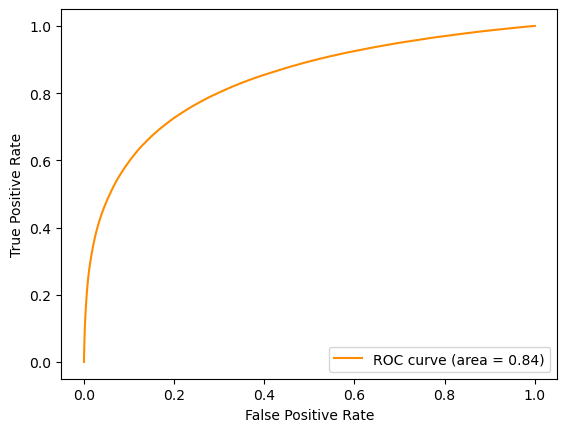

In [49]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [50]:
from sklearn.metrics import (
    roc_curve, auc, precision_score, recall_score,
    f1_score, accuracy_score
)

# Define a function to evaluate and return multiple classification metrics for a given classifier
def evaluate_metrics(clf, name):
    # Get decision scores
    scores = clf.decision_function(X_Test) if hasattr(clf, "decision_function") else clf.predict_proba(X_Test)[:,1]
    # Get binary predictions for metrics that require hard classifications
    preds = clf.predict(X_Test)
    
    # Calculate ROC curve components (FPR, TPR) and AUC
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)
    
    # Calculate Precision
    precision = precision_score(y_Test, preds)
    # Calculate Recall
    recall = recall_score(y_Test, preds)
    # Calculate F1 Score
    f1 = f1_score(y_Test, preds)
    # Calculate Accuracy
    accuracy = accuracy_score(y_Test, preds)
    
    # Calculate the maximal significance using the previously defined function
    sigma = find_best_significance(clf)
    
    # Return all calculated metrics in a list
    return [name, roc_auc, precision, recall, f1, accuracy, sigma]

# Initialize a list to store results for each classifier
results = []
# Evaluate metrics for each of the three classifiers
results.append(evaluate_metrics(clf1, "LogReg")) # LogisticRegression
results.append(evaluate_metrics(clf2, "GNB")) # GaussianNB
results.append(evaluate_metrics(clf3, "SDGC")) # SGDClassifier

# Define the column names for the results DataFrame
columns = ["Model", "AUC", "Precision", "Recall", "F1", "Accuracy", "Max Significance"]
# Create a pandas DataFrame from the collected results for a tabular display
df_results = pd.DataFrame(results, columns=columns)

# Display the DataFrame containing all evaluated metrics
display(df_results)

,Model,AUC,Precision,Recall,F1,Accuracy,Max Significance
0,LogReg,0.858159,0.829581,0.677568,0.745908,0.788469,516.585786
1,GNB,0.811206,0.807706,0.553487,0.656857,0.735011,486.954879
2,SDGC,0.857867,0.823348,0.686343,0.748629,0.788794,514.975250
